# Band Gap Prediction from Chemical Composition
# Materials Informatics Project 2

## What this project does
Predicts the electronic band gap of inorganic materials
using only their chemical formula — no experimental input required.

## Data
- Source: Materials Project database (materialsproject.org)
- Size: 10,000 DFT-computed materials
- Target: Band gap (eV), filtered to 0.1–6.0 eV (semiconductor range)

## Method
1. Retrieved data via Materials Project API (mp-api)
2. Exploratory data analysis — distribution, correlations
3. Featurization: 132 composition features via Matminer MAGPIE preset
4. Trained Random Forest and Gradient Boosting regressors
5. Interpreted model decisions using SHAP values

## Results
| Model              | MAE (eV) | R²    |
|--------------------|----------|-------|
| Random Forest      | 0.474    | 0.793 |
| Gradient Boosting  | 0.608    | 0.704 |

## Key finding
Elemental melting temperature was the strongest predictor
of band gap — reflecting that bond strength governs the
energy splitting between bonding and antibonding states.
Model accuracy degrades below 1 eV and above 5 eV due to
data imbalance and the increasing role of structural features
in those regimes.

## Limitation
Both features and target derive from DFT calculations.
The model learns DFT's internal correlations, not experimental
reality. Validation against experimental band gap measurements
is needed before real-world application.

## Tools
Python · mp-api · Matminer · scikit-learn · SHAP · matplotlib

In [ ]:
!pip install mp_api

In [ ]:
from mp_api.client import MPRester
import pandas as pd

API_KEY = "iJYjGW9Q0LbrzoTeQNNmZqZo7ijGhiFe"


with MPRester(API_KEY) as mpr:
  docs = mpr.materials.summary.search(
      is_stable=True,
      band_gap=(0.1, 6.0),
      fields=[
          "material_id",
          "formula_pretty",
          "band_gap",
          "formation_energy_per_atom",
          "density",
          "volume",
          "nsites",
          "elements",
          "symmetry",
      ],
      num_chunks=10
  )
records= []
for doc in docs:
    records.append({
        "materials_id": doc.material_id,
        "formula": doc.formula_pretty,
        "band_gap": doc.band_gap,
        "formation_energy": doc.formation_energy_per_atom,
        "density": doc.density,
        "volume": doc.volume,
        "nsites": doc.nsites,
        "spacegroup": doc.symmetry.symbol
    })
df = pd.DataFrame(records)
print(df.shape)
print(df.head())
print(df.describe())

Retrieving SummaryDoc documents:   0%|          | 0/10000 [00:00<?, ?it/s]

(10000, 8)
  materials_id formula  band_gap  formation_energy   density       volume  \
0     mp-11107   Ac2O3    3.5219         -3.737668  9.109130    91.511224   
1     mp-32800   Ac2S3    2.2729         -2.493064  6.535149  1118.407852   
2   mp-1183115  AcAlO3    4.1024         -3.690019  8.728230    57.451413   
3     mp-27972   AcBr3    4.1034         -2.494519  5.679086   272.928947   
4     mp-30274   AcBrO    4.2407         -3.218186  7.652290   140.139410   

   nsites spacegroup  
0       5      P-3m1  
1      40      I-42d  
2       5      Pm-3m  
3       8     P6_3/m  
4       6     P4/nmm  
           band_gap  formation_energy       density        volume  \
count  10000.000000      10000.000000  10000.000000  10000.000000   
mean       2.475561         -1.964671      4.411534    657.555876   
std        1.470403          0.930211      1.647522    602.117957   
min        0.102000         -4.402507      0.212291     16.207758   
25%        1.279900         -2.690563      

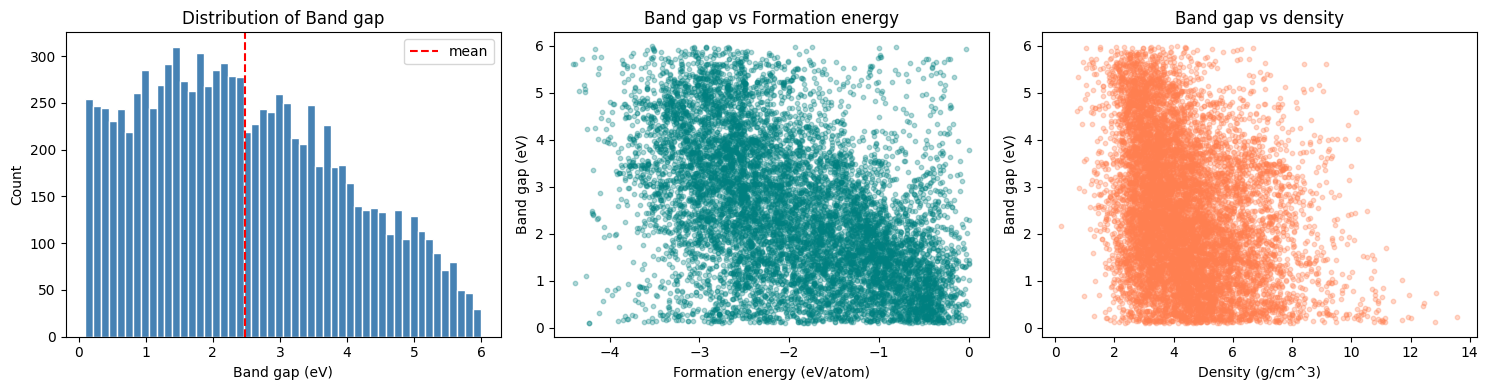


Correlation with band gap:
band_gap            1.000000
formation_energy   -0.487866
density            -0.306385
volume             -0.000748
nsites              0.207125
Name: band_gap, dtype: float64


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].hist(df['band_gap'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Band gap (eV)')
axes[0].set_ylabel('Count')
axes[0].set_title('Distribution of Band gap')
axes[0].axvline(df['band_gap'].mean(),color='red',linestyle= '--',label='mean')
axes[0].legend()

axes[1].scatter(df['formation_energy'], df['band_gap'],
                alpha=0.3, s=10, color='teal')
axes[1].set_xlabel('Formation energy (eV/atom)')
axes[1].set_ylabel('Band gap (eV)')
axes[1].set_title('Band gap vs Formation energy')

axes[2].scatter(df['density'], df['band_gap'],
                alpha=0.3, s=10, color='coral')
axes[2].set_xlabel('Density (g/cm^3)')
axes[2].set_ylabel('Band gap (eV)')
axes[2].set_title('Band gap vs density')

plt.tight_layout()
plt.show()

print("\nCorrelation with band gap:")
print(df[['band_gap', 'formation_energy','density', 'volume', 'nsites']].corr()['band_gap'])







In [ ]:
!pip install matminer

In [ ]:
from matminer.featurizers.composition import ElementProperty
from matminer.featurizers.base import MultipleFeaturizer
from pymatgen.core import Composition

df['composition'] = df['formula'].apply(lambda x: Composition(x))

ep_featurizer = ElementProperty.from_preset("magpie")

df_feat = ep_featurizer.featurize_dataframe(
    df,
    col_id='composition',
    ignore_errors=True
)
print(f"Original features: {df.shape[1]}")
print(f"After featurization: {df_feat.shape[1]}")
print(f"New features added: {df_feat.shape[1]- df.shape[1]}")

ElementProperty:   0%|          | 0/10000 [00:00<?, ?it/s]

Original features: 9
After featurization: 141
New features added: 132


In [ ]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

drops_col = ['material_id', 'formula', 'band_gap',
             'composition', 'elements', 'spacegroup']
feature_cols = [c for c in df_feat.columns
               if c not in drops_col
                and df_feat[c].dtype in ['float64','int64']]

X = df_feat[feature_cols].copy()
Y = df_feat['band_gap'].copy()
mask = X.notna().all(axis=1)
X = X[mask]
Y = Y[mask]

print(f"Training samples: {X.shape[0]}")
print(f"Features used: {X.shape[1]}")

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size=0.2,random_state=42
)

Scaler = StandardScaler()
X_train_scaled = Scaler.fit_transform(X_train)
X_test_scaled = Scaler.transform(X_test)

rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train_scaled, Y_train)
rf_pred = rf.predict(X_test_scaled)

gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
gb.fit(X_train_scaled, Y_train)
gb_pred = gb.predict(X_test_scaled)

print("\n--- Random Forest ---")
print(f"MAE: {mean_absolute_error(Y_test, rf_pred):.3f} eV")
print(f"R2: {r2_score(Y_test, rf_pred):.3f}")


print("\n--- Gradient Boosting ---")
print(f"MAE: {mean_absolute_error(Y_test, gb_pred):.3f} eV")
print(f"R2: { r2_score(Y_test, gb_pred):.3f}")

Training samples: 10000
Features used: 136

--- Random Forest ---
MAE: 0.474 eV
R2: 0.793

--- Gradient Boosting ---
MAE: 0.608 eV
R2: 0.704


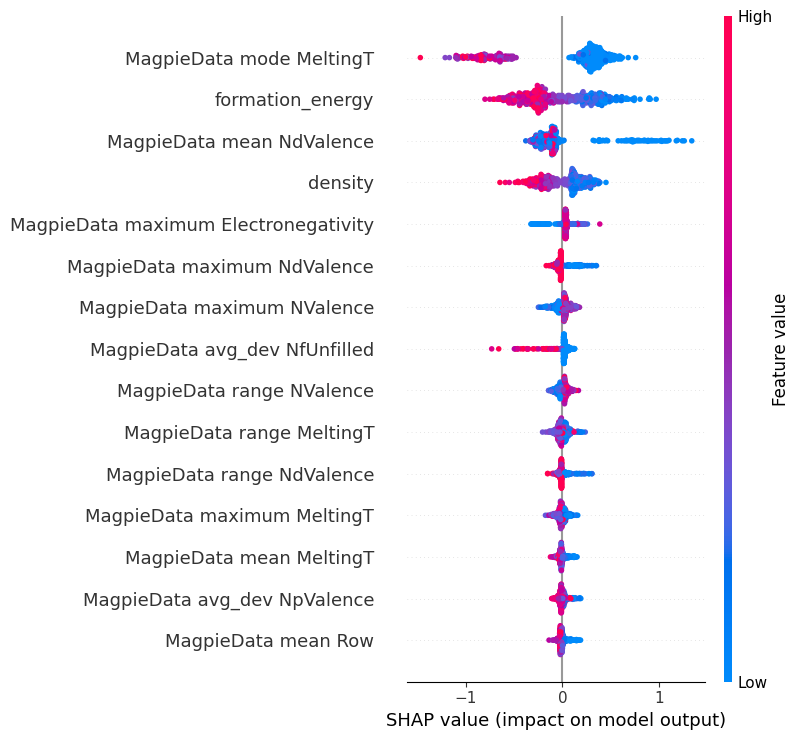

In [ ]:
import shap
import matplotlib.pyplot as plt


explainer = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_test_scaled [:500])


shap.summary_plot(
    shap_values,
    X_test_scaled [:500],
    feature_names=X_train.columns,
    max_display=15,
    show=True
)

NameError: name 'set_xlabel' is not defined

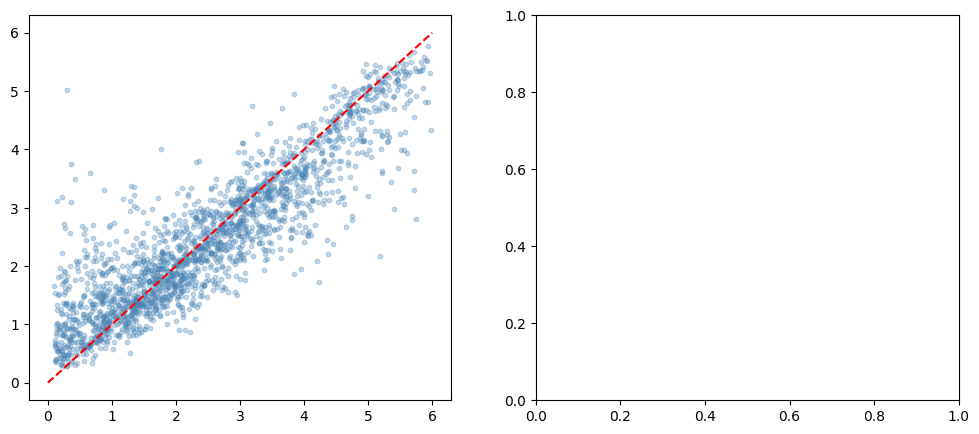

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0]. scatter(Y_test,rf_pred, alpha=0.3, s=10, color='steelblue')
axes[0].plot([0, 6], [0, 6], 'r--', linewidth=1.5, label='perfect prediction')
axes[0],set_Xlabel('Actual band gap(eV)')
axes[0].set_Ylabel('Predicted band gap(eV)')
axes[0].set_title('Random Forest:predicted vs actual')
axes[0].legend()

residuals = Y_test - rf_pred
axes[1].scatter(Y_test, residuals, alpha=0.3, s=10, color='coral')
axes[1].axhline(0, color='black', linewidth=1.5, linestyle='--')
axes[1].set_Xlabel('Actual band gap (eV)')
axes[1].set_Ylabel('Resifdual (actual-predicted)')
axes[1].set_title('Where the model fails')

plt.tight_layout()
plt.show()

